# **Installing Packages**

In [ ]:
!pip install facenet-pytorch tqdm opencv-python

# **Mouting Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Imports**

In [ ]:
import os
from glob import glob
import random
import cv2
from tqdm import tqdm
import torch
import torch.optim as optim
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image

data_root = "/content/drive/MyDrive/DeepfakeDataset/FaceForensics_Frames"
categories = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures", "original"]

train_ratio, val_ratio, test_ratio = 0.7, 0.1, 0.2
batch_size = 32


# **Dataset Class Definition**

In [ ]:
class DeepfakeDataset(Dataset):
    def __init__(self, root_dir, categories, transform=None):
        self.data = []
        self.transform = transform

        for cat in categories:
            label = 0 if cat.lower() == "original" else 1
            folder_path = os.path.join(root_dir, cat)
            video_folders = os.listdir(folder_path)

            for vid in tqdm(video_folders, desc=f"Loading {cat}"):
                vid_path = os.path.join(folder_path, vid)
                if not os.path.isdir(vid_path):
                    continue
                for img_path in glob(os.path.join(vid_path, "*.jpg")) + glob(os.path.join(vid_path, "*.png")):
                    self.data.append((img_path, label))

        random.shuffle(self.data)
        print(f"✅ Total images loaded: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


# **Data Loading**

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = DeepfakeDataset(data_root, categories, transform)

train_size = int(train_ratio * len(dataset))
val_size = int(val_ratio * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
print(f"📊 Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


Loading original: 100%|██████████| 1000/1000 [01:46<00:00,  9.41it/s]


✅ Total images loaded: 7893
📊 Train: 5525, Val: 789, Test: 1579


# **Model Initialisation**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def get_efficientnet_b0(num_classes=2, pretrained=True):
    model = models.efficientnet_b0(weights='IMAGENET1K_V1' if pretrained else None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

model = get_efficientnet_b0(num_classes=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


Using device: cuda


100%|██████████| 20.5M/20.5M [00:00<00:00, 163MB/s]


# **Model Training**

In [ ]:
def train_model(model, train_loader, val_loader, epochs=1):
    scaler = torch.cuda.amp.GradScaler()

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = train_correct / len(train_loader.dataset)
        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        avg_val_loss = val_loss / len(val_loader)

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

    return history


In [ ]:
num_epochs = 50
history= train_model(model, train_loader, val_loader, epochs=num_epochs)

Epoch 1/50 - Training: 100%|██████████| 173/173 [1:50:24<00:00, 38.29s/it]


Epoch 1/50 | Train Loss: 0.5727, Train Acc: 69.74% | Val Loss: 0.4712, Val Acc: 78.07%


Epoch 2/50 - Training: 100%|██████████| 173/173 [00:42<00:00,  4.07it/s]


Epoch 2/50 | Train Loss: 0.3500, Train Acc: 84.60% | Val Loss: 0.3855, Val Acc: 83.14%


Epoch 3/50 - Training: 100%|██████████| 173/173 [00:41<00:00,  4.13it/s]


...

Epoch 48/50 | Train Loss: 0.0106, Train Acc: 99.64% | Val Loss: 0.4109, Val Acc: 91.89%


Epoch 49/50 - Training: 100%|██████████| 173/173 [00:41<00:00,  4.19it/s]


Epoch 49/50 | Train Loss: 0.0079, Train Acc: 99.73% | Val Loss: 0.4796, Val Acc: 90.87%


Epoch 50/50 - Training: 100%|██████████| 173/173 [00:41<00:00,  4.14it/s]


Epoch 50/50 | Train Loss: 0.0059, Train Acc: 99.80% | Val Loss: 0.4686, Val Acc: 90.24%


# **Saving The Model**

In [ ]:
torch.save({
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "epoch": num_epochs,
    "train_history": {
        "train_losses":history['train_loss'],
        "train_acc":history['train_acc'],
        "val_losses": history['val_loss'],
        "val_acc": history['val_acc']
    }
}, "checkpoint_new.pth")


print("Model saved successfully!")

Model saved successfully!


# **Loading The model State**

In [ ]:
ckpt = torch.load(
    "/content/drive/MyDrive/DeepfakeDataset/checkpoint_new.pth",
    map_location=device
)

model = get_efficientnet_b0(num_classes=2)
model.load_state_dict(ckpt["model_state"])

optimizer = optim.Adam(model.parameters(), lr=1e-4)
optimizer.load_state_dict(ckpt["optimizer_state"])

start_epoch = ckpt["epoch"]
history = ckpt["train_history"]

# **Testing The Model**

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

model.eval()
test_correct = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        test_correct += (preds == labels).sum().item()

test_acc = test_correct / len(test_loader.dataset)
print(f"\n✅ Final Test Accuracy: {test_acc*100:.2f}%")

Testing: 100%|██████████| 50/50 [24:01<00:00, 28.83s/it]


✅ Final Test Accuracy: 89.80%


# **Storing The Test Results**

In [ ]:
np.savez("/content/drive/MyDrive/DeepfakeDataset/test_results.npz",
         preds=np.array(all_preds),
         labels=np.array(all_labels),
         accuracy=test_acc)

# **Loading The Test Results**

In [ ]:
data = np.load("/content/drive/MyDrive/DeepfakeDataset/test_results.npz")

all_preds = data["preds"]
all_labels = data["labels"]
accuracy = float(data["accuracy"])

print(preds[:5])
print(labels[:5])
print("Accuracy:", accuracy)

# **Plotting Loss And Accuracy curves for Train And Validation Dataset**

In [ ]:
def plot_training_curves(train_losses, val_losses, train_accs, val_accs):

    epochs_range = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 10))

    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, train_losses, marker='o')
    plt.title("Training Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, train_accs, marker='o')
    plt.title("Training Accuracy vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(epochs_range, val_losses, marker='o')
    plt.title("Validation Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(epochs_range, val_accs, marker='o')
    plt.title("Validation Accuracy vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


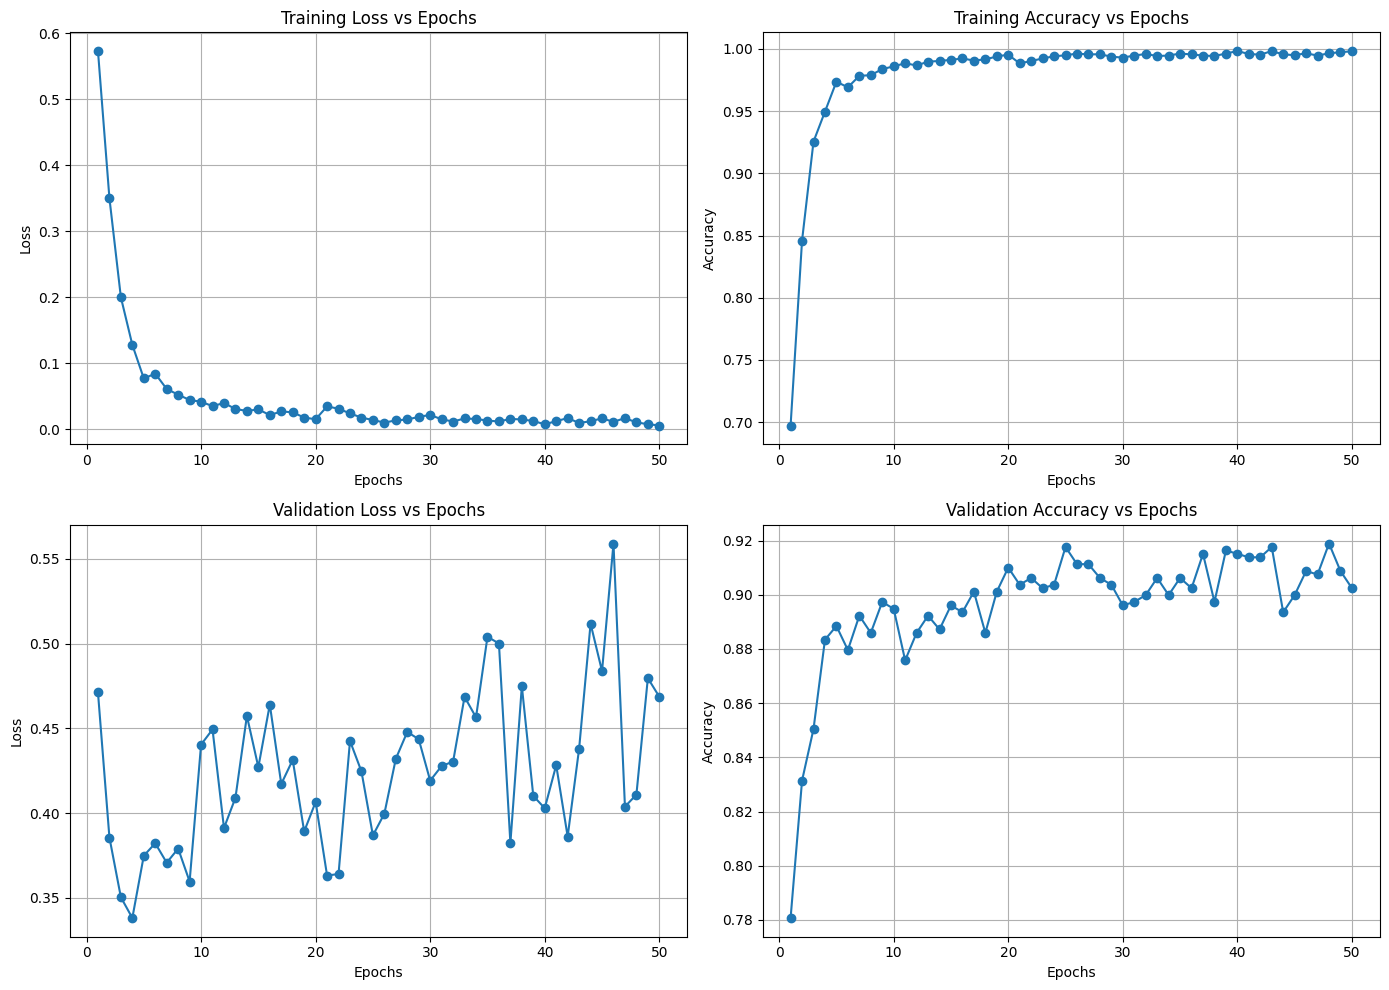

In [ ]:
plot_training_curves(history['train_loss'], history['val_loss'], history['train_acc'],history['val_acc'])

# **Classification Repost And Confusion Matrix**


Classification Report:
               precision    recall  f1-score   support

     Class 0       0.89      0.89      0.89       756
     Class 1       0.90      0.90      0.90       823

    accuracy                           0.90      1579
   macro avg       0.90      0.90      0.90      1579
weighted avg       0.90      0.90      0.90      1579


Confusion Matrix:
 [[675  81]
 [ 80 743]]


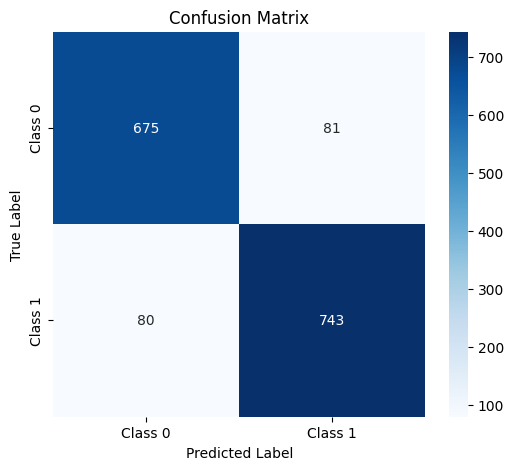

In [ ]:
report = classification_report(all_labels, all_preds, target_names=["Class 0", "Class 1"])
print("\nClassification Report:\n", report)

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Class 0", "Class 1"],
            yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# **Importing Face Detection Model**

In [ ]:
from facenet_pytorch import MTCNN

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using:", device)

model.eval()

mtcnn = MTCNN(keep_all=True, device=device)


Using: cuda


# **Video Preprocessing**

In [ ]:
def extract_frames(video_path, num_frames=5):
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_count <= 1:
        return frames

    frame_indices = np.linspace(0, frame_count - 1, num_frames, dtype=int)

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)

    cap.release()
    return frames


In [ ]:
def detect_biggest_face(frame):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    boxes, _ = mtcnn.detect(rgb)

    if boxes is None or len(boxes) == 0:
        return None, None

    largest = max(boxes, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))
    return largest, rgb

def crop_face(frame, box):
    x1, y1, x2, y2 = map(int, box)
    face = frame[y1:y2, x1:x2]
    if face.size == 0:
        return None
    return face

from torchvision import transforms

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def classify_face(face):
    tensor = preprocess(face).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(tensor)
    prob = F.softmax(out, dim=1)
    confidence, pred = torch.max(prob, dim=1)
    return int(pred.item()), float(confidence.item())


In [ ]:
def process_video(video_path):
    frames = extract_frames(video_path)

    video_predictions = []
    video_confidences = []
    boxes_per_frame = []
    cropped_faces = []

    for frame in frames:
        box, rgb = detect_biggest_face(frame)
        boxes_per_frame.append(box)

        if box is None:
            video_predictions.append(0)
            video_confidences.append(0)
            cropped_faces.append(None)
            continue

        face = crop_face(rgb, box)
        cropped_faces.append(face)

        pred, conf = classify_face(face)
        video_predictions.append(pred)
        video_confidences.append(conf)

    final_pred = max(set(video_predictions), key=video_predictions.count)
    return frames, boxes_per_frame, video_predictions, video_confidences, final_pred


# **Loading The Videos**

In [ ]:
VIDEO_FOLDER_PATH = "/content/drive/MyDrive/DeepfakeDataset/FaceForensics_demo"

video_files = [f for f in os.listdir(VIDEO_FOLDER_PATH) if f.endswith(".mp4")]
video_files = video_files[:10]

results = {}

for v in tqdm(video_files, desc="Processing Videos"):
    video_path = os.path.join(VIDEO_FOLDER_PATH, v)
    data = process_video(video_path)
    results[v] = data


Processing Videos: 100%|██████████| 10/10 [00:45<00:00,  4.52s/it]


# **Output Visualisation**

In [ ]:
def visualize_video(video_name, video_result):
    frames, boxes, frame_preds, frame_confs, final_pred = video_result

    plt.figure(figsize=(20, 4))

    fig = plt.gcf()
    plt.subplots_adjust(left=0.02, right=0.98, top=1, bottom=0.2, wspace=0.01, hspace=0.01)
    fig.tight_layout(pad=0)

    border = plt.Rectangle(
        (0.005, 0.005),
        0.99, 0.99,
        fill=False,
        edgecolor="black",
        linewidth=2,
        transform=fig.transFigure,
        zorder=10
    )
    fig.patches.append(border)

    plt.subplots_adjust(wspace=0.1, hspace=0.1, top=0.78)

    for i, frame in enumerate(frames):
        plt.subplot(1, 5, i + 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        box = boxes[i]
        if box is not None:
            x1, y1, x2, y2 = map(int, box)

            if frame_preds[i] == 1:
                color = "lime"
                conf_text = f"{frame_confs[i]*100:.1f}%"
            else:
                color = "red"
                conf_text = f"{(1-frame_confs[i])*100:.1f}%"

            plt.gca().add_patch(plt.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2,
                edgecolor=color,
                facecolor='none'
            ))

            plt.text(
                x1,
                y1 - 10,
                conf_text,
                color=color,
                fontsize=10,
                bbox=dict(facecolor='black', alpha=0.4, pad=2)
            )

    final_label = "FAKE" if final_pred == 1 else "REAL"
    title_color = "darkgreen" if final_pred == 1 else "red"

    plt.suptitle(
        f"{video_name}  |  Final Prediction: {final_label}",
        fontsize=16,
        color=title_color,
        y=0.1
    )

    plt.show()


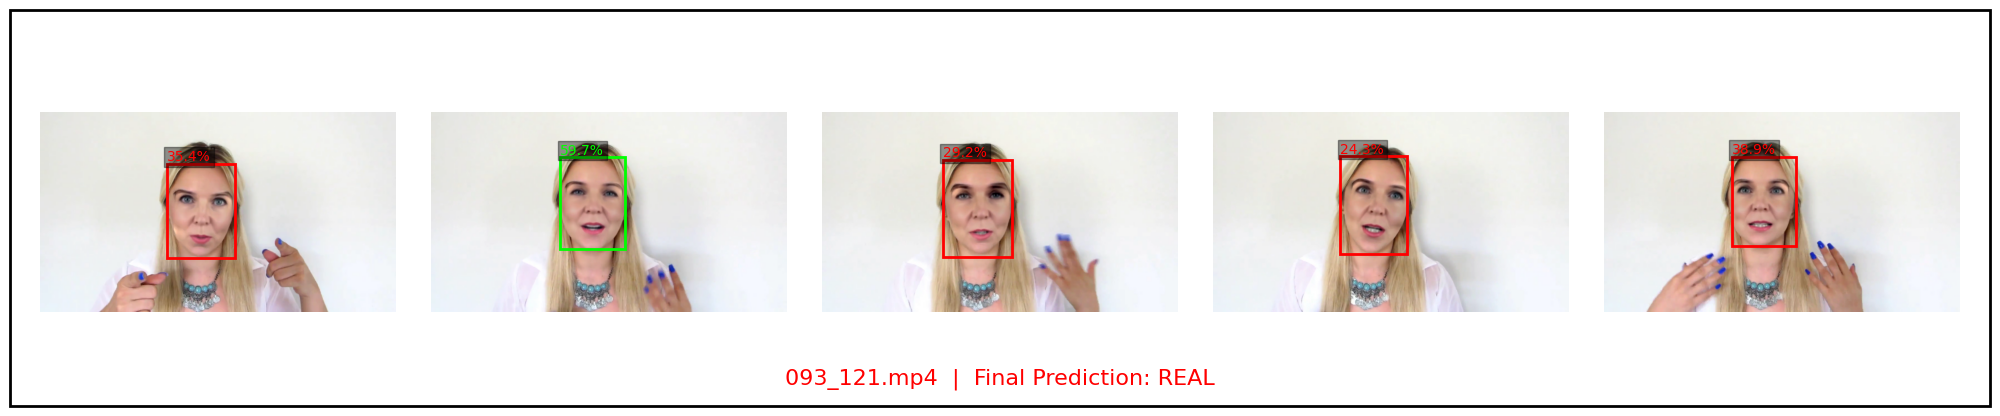

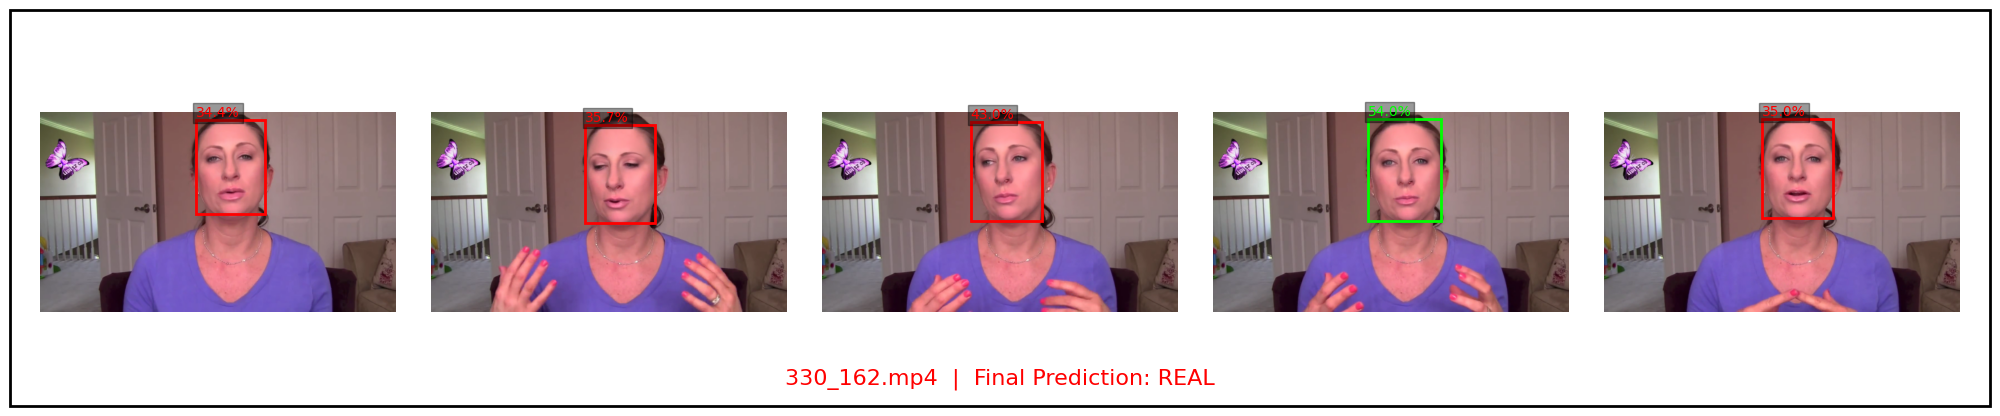

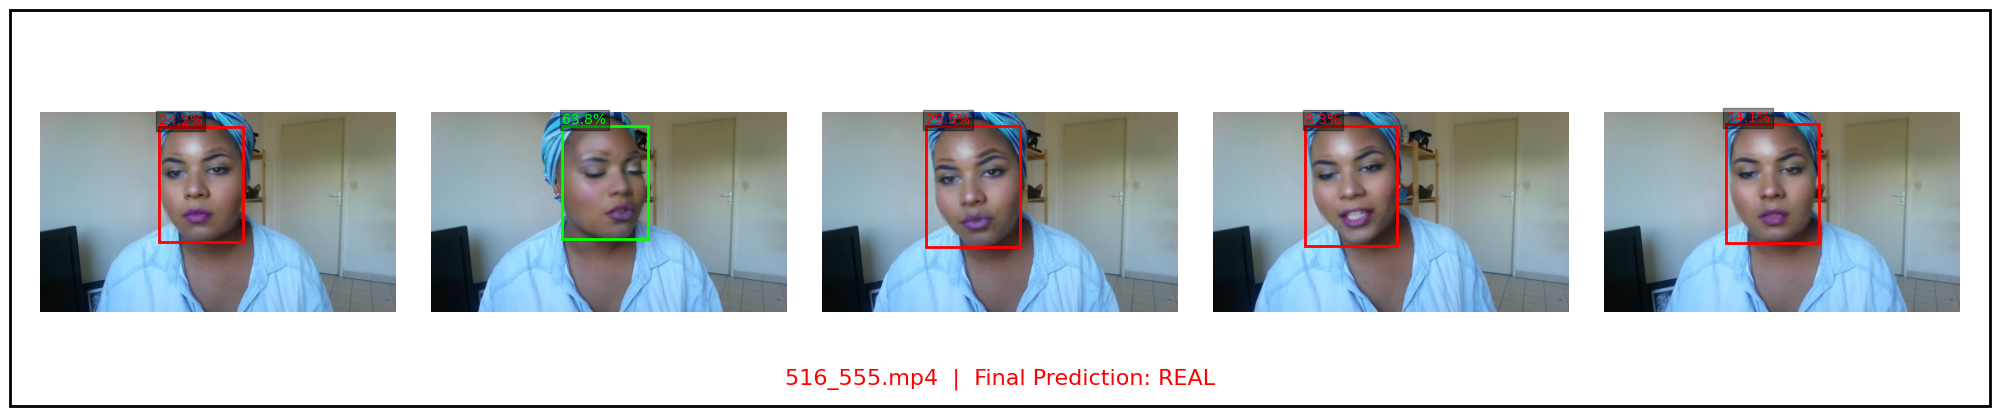

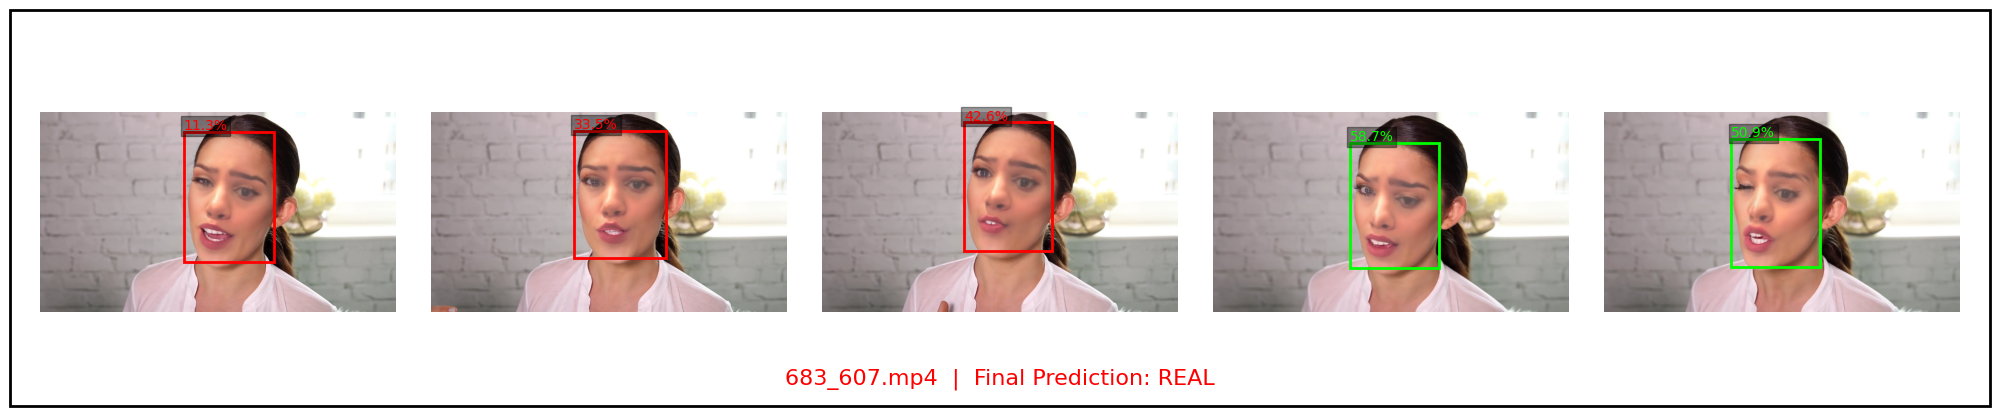

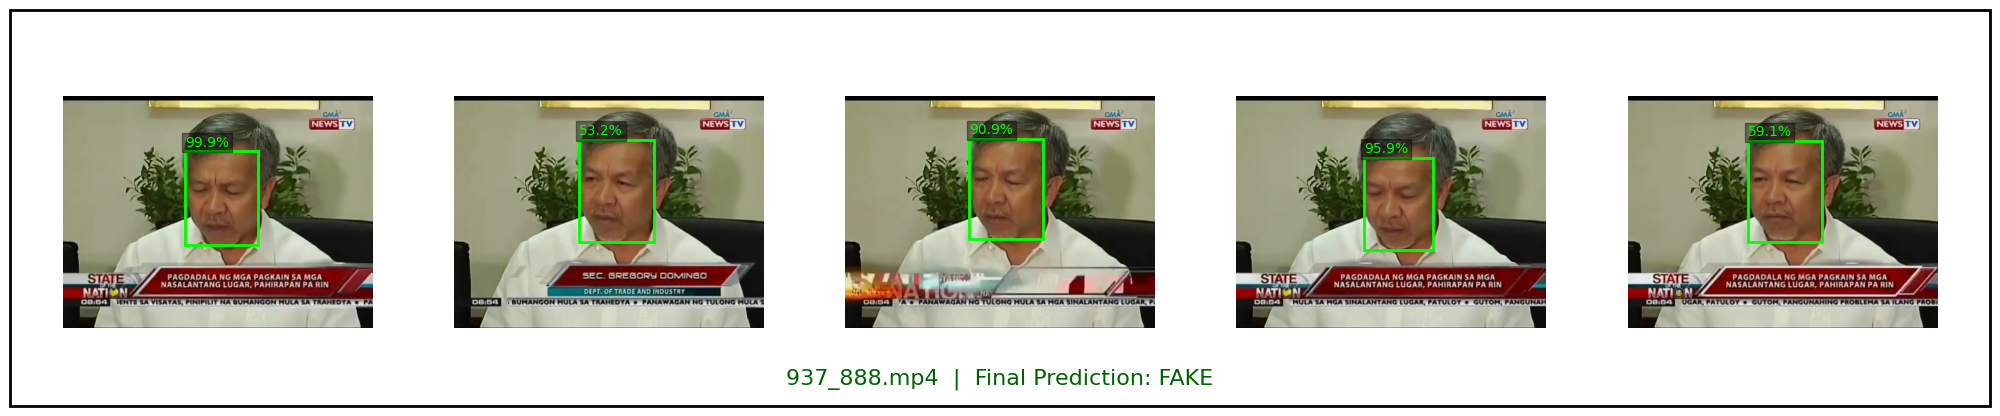

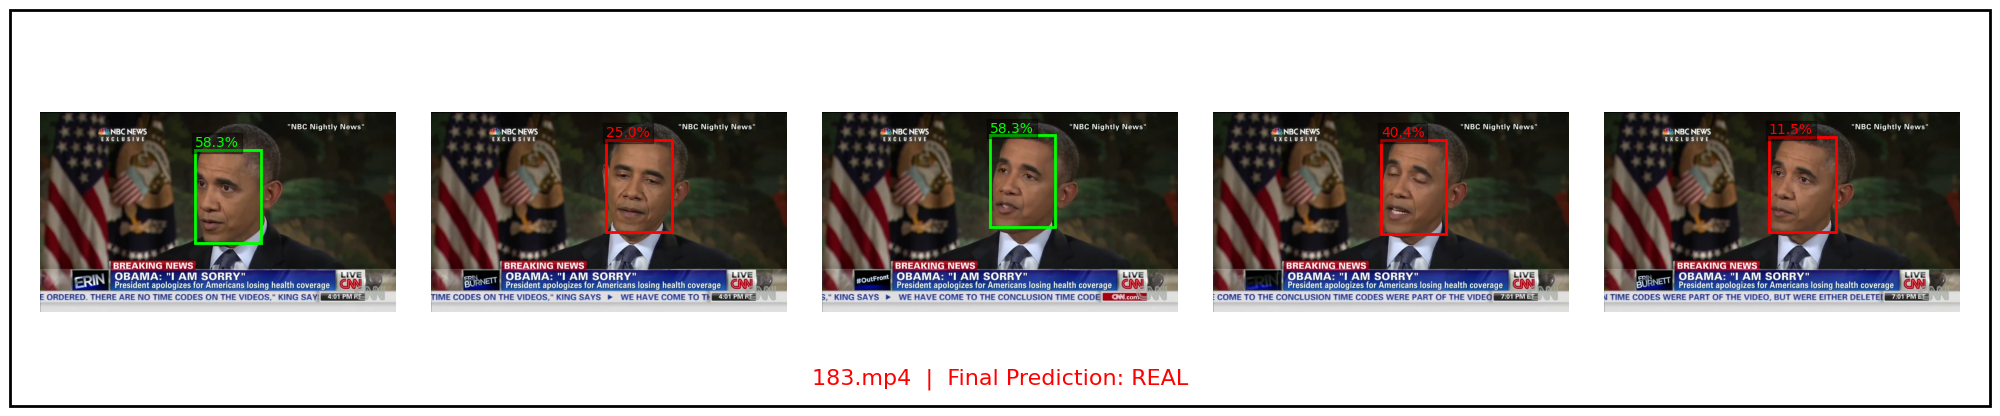

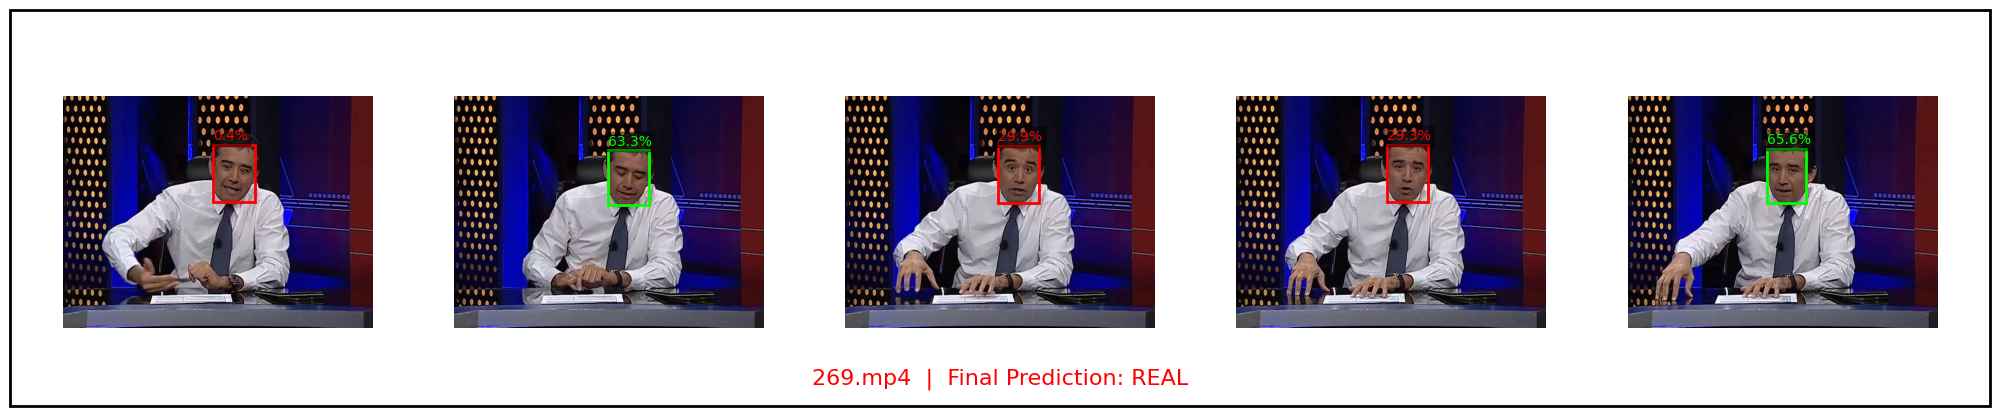

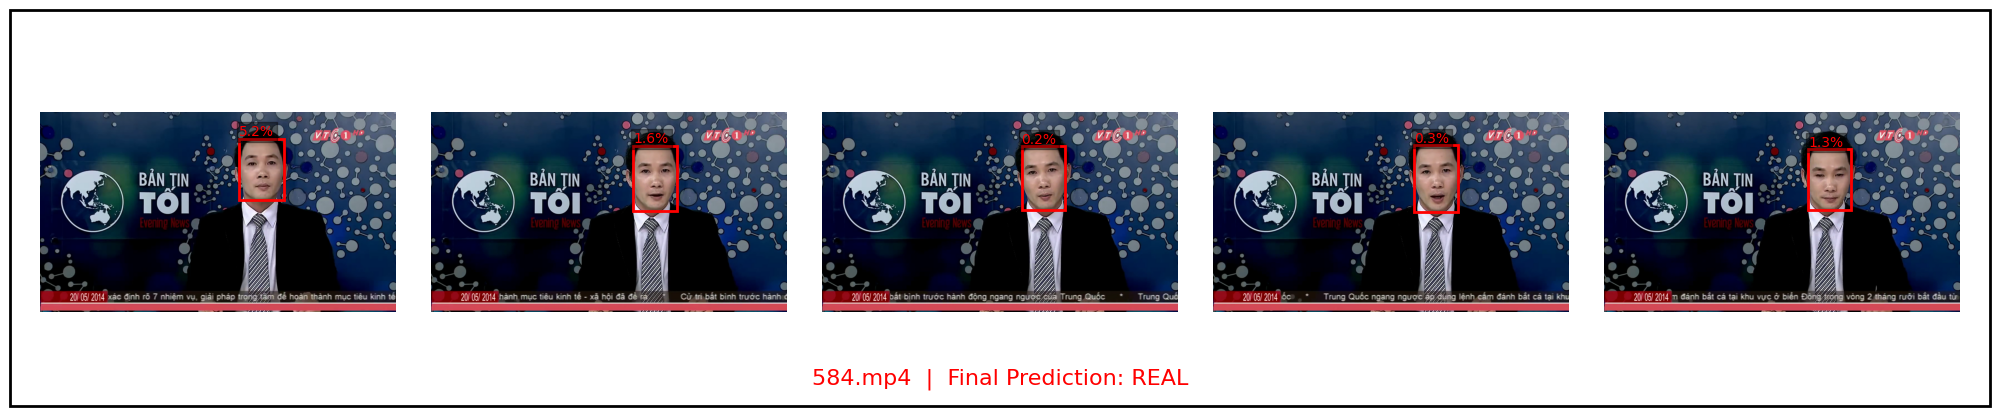

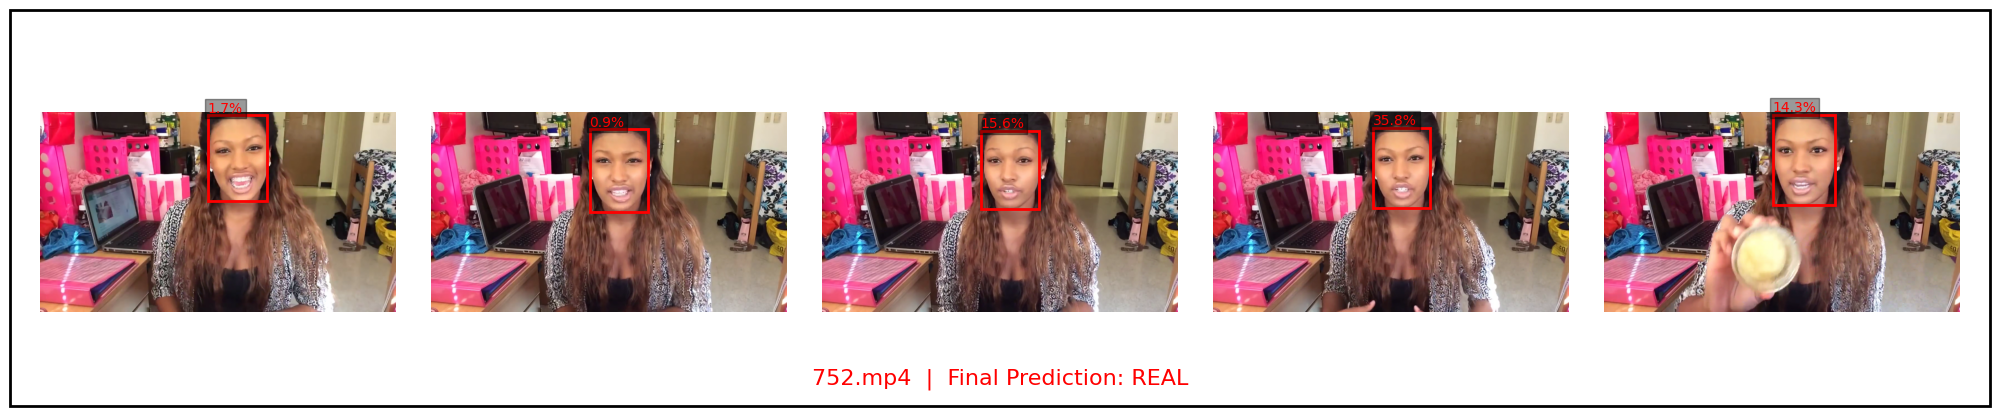

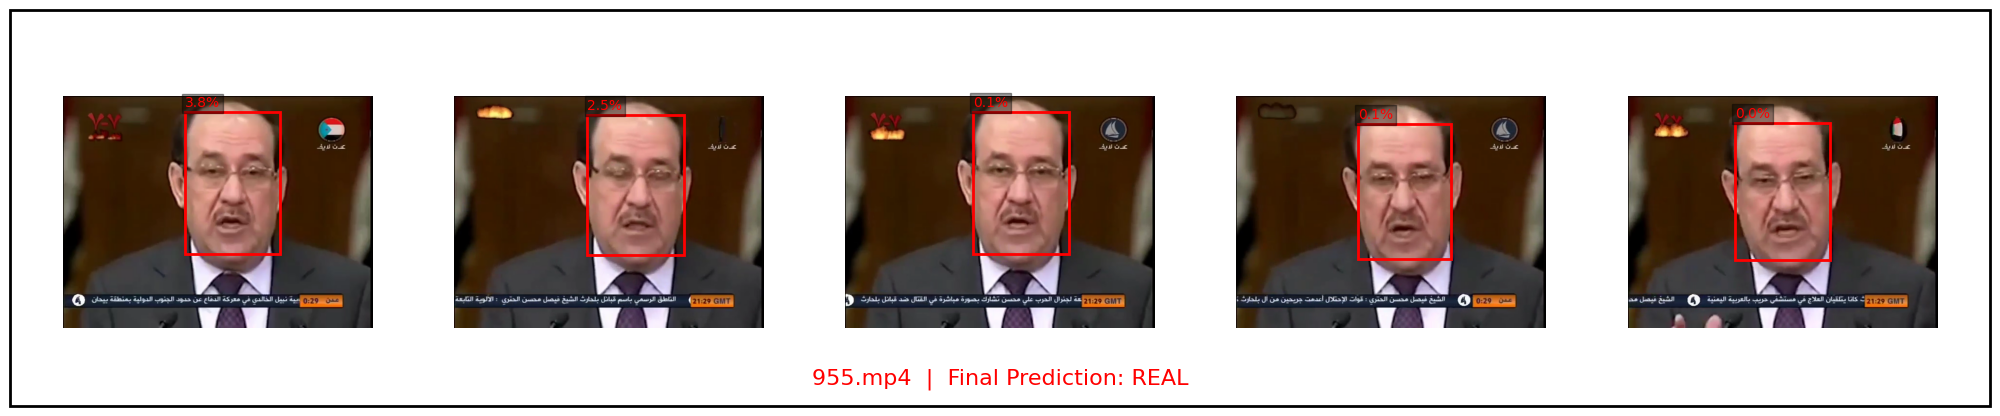

In [ ]:
for vid in video_files:
    visualize_video(vid, results[vid])